In [1]:
# %load_ext autoreload
# %autoreload 2
%time

CPU times: user 1 µs, sys: 1 µs, total: 2 µs
Wall time: 4.53 µs


In [2]:
import sys, os
sys.path.append("../../")  # if needed
import pandas as pd
import data_loading as dl
import numpy as np
import matplotlib.pyplot as plt
from numu_tki.cc0pi_analyzer import apply_ccnp0pi_stv
from cc0pi_cached import load_runs_with_cc0pi_bdt


In [3]:
RUN = ["1"]
blinded = True

rundata, mc_weights, data_pot = load_runs_with_cc0pi_bdt(
    ["1"],
    model_path="/exp/uboone/app/users/rlalnunt/PELEE_BDT/cc0pi_fstrack_pid_softprob.json",
    data="bnb",
    loadshowervariables=False,
    loadnumuvariables=True,
    load_numu_tki=False,
    loadpi0variables=False,
    loadrecoveryvars=False,
    loadsystematics=True,
    blinded=True,
    enable_cache=True,   # turns on the HDF cache
    overwrite=False,      # don’t overwrite cached result
    use_bdt=False
)

Loading run 1
Running the CC0pi-BDT....


In [5]:
mc = rundata["mc"]
#print(mc)
print("mc_is_cc1p0pi_signal" in rundata["mc"].columns)
#print(mc["mc_num_protons"].values)
print(len(mc["mc_is_cc0pi_signal"]))


True
1020773


In [6]:
print("sel_CCNp0pi" in rundata["mc"].columns)

True


In [7]:
sel_mc_1mu1p = mc[mc['sel_CC1p0pi'] == True ] # Truth-Level Study
pre_mc_1mu1p = mc[mc['sel_CCNp0pi'] == True ]

In [8]:
selection    = sel_mc_1mu1p 
preselection = pre_mc_1mu1p 

13182


/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del sys.path[0]
/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

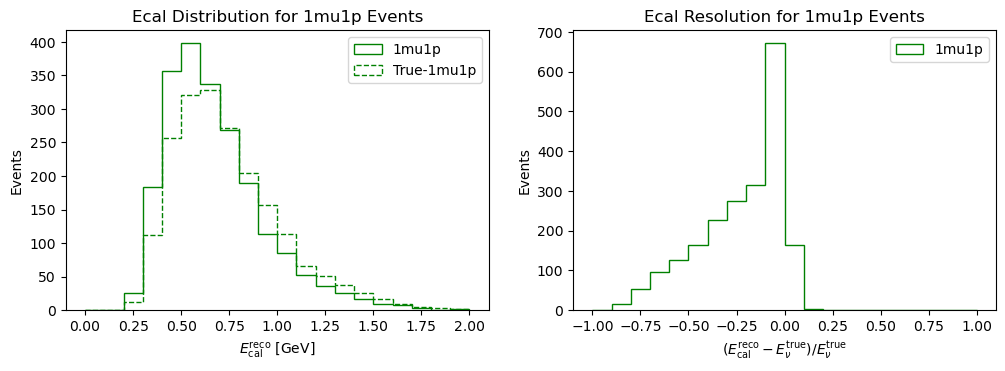

In [9]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)

# Compute reco neutrino energy via Ecal method
reco_ecal_energy   = sel_mc_1mu1p["Ecal"].values
true_ecal_energy   = sel_mc_1mu1p["mc_Ecal"].values
true_nu_energy     = sel_mc_1mu1p["nu_e"].values
# Compute Ecal resolution
ecal_resolution_1mu1p = (reco_ecal_energy - true_nu_energy) / true_nu_energy
print(len(ecal_resolution_1mu1p))

# Add to DataFrame
sel_mc_1mu1p['Ecal_1mu1p'] = ecal_resolution_1mu1p
sel_mc_1mu1p['E_Reco'] = reco_ecal_energy
sel_mc_1mu1p['E_True'] = true_nu_energy

plt.hist(sel_mc_1mu1p['E_Reco'], bins=20, weights=sel_mc_1mu1p['weights'], range=(0, 2),
         histtype='step', linestyle='-', color='Green', label='1mu1p')
plt.hist(sel_mc_1mu1p['mc_Ecal'], bins=20, weights=sel_mc_1mu1p['weights'], range=(0, 2),
         histtype='step', linestyle='--', color='Green', label='True-1mu1p')
plt.xlabel('$E_{\mathrm{cal}}^{\mathrm{reco}}$ [GeV]')
plt.ylabel('Events')
plt.title('Ecal Distribution for 1mu1p Events')
plt.legend()

plt.subplot(2, 2, 2)
plt.hist(sel_mc_1mu1p['Ecal_1mu1p'], bins=20, weights=sel_mc_1mu1p['weights'], range=(-1, 1),
         histtype='step', linestyle='-', color='Green', label='1mu1p')
plt.xlabel(r"$(E_{\mathrm{cal}}^{\mathrm{reco}} - E_\nu^{\mathrm{true}})/E_\nu^{\mathrm{true}}$")
plt.ylabel('Events')
plt.title('Ecal Resolution for 1mu1p Events')
plt.legend()

## ECAL Systematics

In [10]:
from microfit import selections as sel
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Choose your selection and preselection category
## 1mu1p
selection    =  "sel_CC1p0pi" #"SIGNAL_1MU1P"#"TKI_1mu1p" #"TKI_1mu1p" #"SG_1MU1P" 
preselection = "sel_CCNp0pi" #"SIGNAL_1MUNP"#"SG_1MUNP"NUMU


# Build the full query (e.g. sel_CCNp0pi and sel_CC1p0pi)
query_1mu1p = f"{sel.preselection_categories[preselection]['query']} and {sel.selection_categories[selection]['query']}"
sel_title_1mu1p = sel.selection_categories[selection]['title']

#print(type(query_1e1p))
all_mc      = pd.concat([df for k, df in rundata.items() if k not in ['data', 'ext']])

sel_mc_1mu1p    = all_mc.query(query_1mu1p, engine='python')

In [10]:
print(sel_mc_1mu1p)

         CosmicIPAll3D  mcf_npp  isVtxInFiducial  npi0  knobAxFFCCQEup  \
8            82.607292        0             True     0        1.216392   
42         9999.000000        0             True     0        1.524799   
157        9999.000000        0             True     0        1.187178   
243        9999.000000        0             True     0        1.171366   
275         148.899216        0             True     0        1.120511   
...                ...      ...              ...   ...             ...   
1020331      58.624912        0             True     0        1.078309   
1020530    9999.000000        0             True     0        1.000000   
1020540     103.883125        1             True     0        1.000000   
1020685    9999.000000        0             True     0        1.133450   
1020754    9999.000000        0             True     0        3.225442   

         mcf_pass_cccpi  reco_nu_vtx_sce_z  knobVecFFCCQEdn  mcf_pass_ccnopi  \
8                     0        

In [11]:
print(sel_mc_1mu1p['Ecal'])

8          1.472764
42         0.452176
157        0.738152
243        0.523130
275        0.553329
             ...   
1020331    0.654256
1020530    0.331638
1020540    0.546902
1020685    0.482978
1020754    0.502801
Name: Ecal, Length: 13182, dtype: float64


### Calculating the metrics

In [12]:
# total candidate signal events (all_mc)
all_sig = (all_mc['sel_CC1p0pi'] == True)
tot_all_sig = all_mc.loc[all_sig, 'weights'].sum()
print('Total candidate signal events:', tot_all_sig)

# apply your full selection (preselection + selection)
all_predict = all_mc.query(query_1mu1p, engine='python')

is_sig = (all_predict['sel_CC1p0pi'] == 1)
tot_sig = all_predict.loc[is_sig, 'weights'].sum()
tot_bkg = all_predict.loc[~is_sig, 'weights'].sum()
tot_evt = all_predict['weights'].sum()
print('After cuts:')
print('Total signal events:', tot_sig)
print('Total background events:', tot_bkg)
print('Total events:', tot_evt)
print('sig + bkg =', tot_sig + tot_bkg)
print()

efficiency = (tot_sig / tot_all_sig) * 100
purity = (tot_sig / tot_evt) * 100
print('Efficiency:', efficiency)
print('Purity:', purity)


Total candidate signal events: 2111.5238326986128
After cuts:
Total signal events: 2111.5238326986128
Total background events: 0.0
Total events: 2111.5238326986128
sig + bkg = 2111.5238326986128

Efficiency: 100.0
Purity: 100.0


In [14]:
from microfit import selections as sel
import numpy as np
import pandas as pd

selection    = "sel_CC1p0pi"
preselection = "sel_CCNp0pi"

pre_q  = sel.preselection_categories[preselection]["query"]
sel_q  = sel.selection_categories[selection]["query"]
reco_q = f"({pre_q}) and ({sel_q})"

all_mc = pd.concat([df for k, df in rundata.items() if k not in ['data', 'ext']])

def wsum(df):
    return df["weights"].sum()

# 1) Truth signal (no reco cuts)

N_tot     = mc["weights"].sum()
sig_all   = mc.query(signal_q, engine="python")
sel_all   = mc.query(reco_q, engine="python")
sel_sig   = mc.query(f"{signal_q} and {reco_q}", engine="python")

N_sig_all = wsum(sig_all)
N_sel_all = wsum(sel_all)
N_sel_sig = wsum(sel_sig)

eff  = N_sel_sig / N_sig_all if N_sig_all > 0 else np.nan
pur  = N_sel_sig / N_sel_all if N_sel_all > 0 else np.nan

print(f"Truth signal (no reco cuts):    {N_sig_all:.3f}")
print(f"Reco selected (pre+sel):        {N_sel_all:.3f}")
print(f"Selected signal (truth+reco):   {N_sel_sig:.3f}")
print(f"Efficiency: {eff*100:.2f} %")
print(f"Purity:     {pur*100:.2f} %")


NameError: name 'signal_q' is not defined

## Calculating the integrated flux

In [15]:
# Zarko Pavlovic, Jun 22 2020
# /pnfs/uboone/persistent/uboonebeam/bnb_gsimple/bnb_gsimple_fluxes_01.09.2019_463_hist/readme.txt

Nominal_UB_XY_Surface = 256.35*233. # cm2
SoftFidSurface = 236. * 210.  # cm2
POTPerSpill = 4997.*5e8

# import uproot

# FluxFile = uproot.open('/pnfs/uboone/persistent/uboonebeam/bnb_gsimple/bnb_gsimple_fluxes_01.09.2019_463_hist/MCC9_FluxHist_volTPCActive.root')#['hEnue_cv']
# HistoFlux = FluxFile['hEnue_cv']
HistoFlux_int = 593641.00 # retrieved from the root file itself by running hEnue_cv->Integral()
#HistoFlux_int = 1.1007862e+08 # for hEnumu_cv

IntegratedFlux = (HistoFlux_int * data_pot / POTPerSpill / Nominal_UB_XY_Surface)
print(IntegratedFlux)

664311487.6259646


In [16]:
from microfit import selections as sel
selection = "sel_CC1p0pi"
preselection = "sel_CCNp0pi"
query = f"{sel.preselection_categories[preselection]['query']} and {sel.selection_categories[selection]['query']}"
print(query)

sel_CCNp0pi == True and sel_CC1p0pi == True


### ECAL Systematics

In [12]:
import pandas as pd
import numpy as np
from microfit.histogram import Binning, RunHistGenerator

stub = pd.DataFrame({
    "Ecal":         pd.Series([], dtype=float),
    "sel_CCNp0pi":  pd.Series([], dtype=bool),
    "sel_CC1p0pi":  pd.Series([], dtype=bool),
})

# rundata_stub = {
#     "data": stub.copy(),
#     "ext":  stub.copy(),
#     "mc":   mc,               #analyzed MC with Ecal & selection flags
# }
empty_like_mc = mc.head(0).copy()

rundata_stub = {
    "dirt": empty_like_mc.copy(),
    "data": empty_like_mc.copy(),  # ok even if blinded; it’s empty
    "ext":  empty_like_mc.copy(),
    "mc":   mc,                    # your analyzed MC
}

binning_def = ("Ecal", 24, (0.0, 2.0), r"Ecal (GeV)")
binning = Binning.from_config(*binning_def)
binning.label = "BDT_1mu1p"
binning.set_selection(selection, preselection)
binning

signal_generator_1mu1p = RunHistGenerator(
    rundata_stub,
    binning,
    data_pot=data_pot,
    showdata=False,   # optional
)
total_prediction_1mu1p = signal_generator_1mu1p.get_total_prediction(include_multisim_errors=True)


../../microfit/run_plotter.py:132: UserWarning: No signal category found in the MC hists. Not separating signal.
  warnings.warn("No signal category found in the MC hists. Not separating signal.")


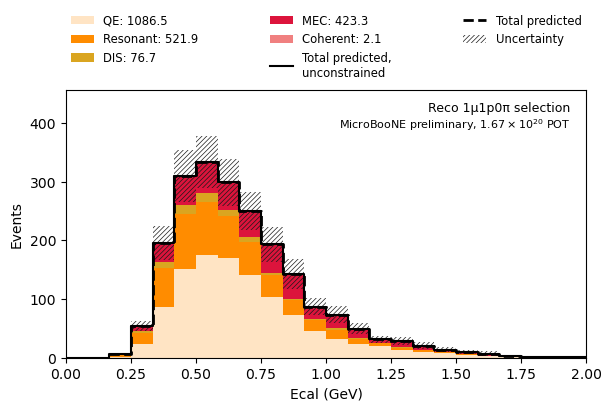

In [13]:
from microfit.run_plotter import RunHistPlotter

plotter = RunHistPlotter(signal_generator_1mu1p)
ax = plotter.plot(
    category_column="interaction",
    include_multisim_errors=True,
    add_ext_error_floor=False,
    show_data_mc_ratio=False,
    show_chi_square=False,
)

## FRACTIONAL UNCERTAINTY

In [16]:
# from microfit import histogram as hist
# from microfit import detsys


# reco_delta_pT   = sel_mc_1mu1p["delta_pT"].values
# sel_mc_1mu1p['delta_pT'] = reco_delta_pT

# for k, df in rundata.items():
#     if df is None:
#         continue
#     # ECal for all events
#     df["ECal_all"] = (
#         sel_mc_1mu1p["Ecal"]
#     )
#     df["delta_pT"] = (
#         sel_mc_1mu1p["delta_pT"]
#     )
#     # ECal only for pT<0.4
#     mask = df["delta_pT"] < 0.4
#     df["ECal_pT04"] = np.nan
#     df.loc[mask, "ECal_pT04"] = df.loc[mask, "ECal_all"]
    
#     mask = df["delta_pT"] < 0.3
#     df["ECal_pT03"] = np.nan
#     df.loc[mask, "ECal_pT03"] = df.loc[mask, "ECal_all"]
    
#     mask = df["delta_pT"] < 0.2
#     df["ECal_pT02"] = np.nan
#     df.loc[mask, "ECal_pT02"] = df.loc[mask, "ECal_all"]
    


# #IntegratedFlux = 1

# #edges = np.linspace(0.0, 1.5, 15) # OG
# edges = np.linspace(0.0, 2.0, 24)
# my_vars = [
#     ("ECal_all",  edges, r"ECal (No cut)"),
#     ("ECal_pT04", edges, r"ECal ($p_T<0.4$)"),
#     ("ECal_pT03", edges, r"ECal ($p_T<0.3$)"),
#     ("ECal_pT02", edges, r"ECal ($p_T<0.2$)"),
# ]

# for var_name, var_edges, var_tex in my_vars:
#     #  Binning from Ecal new df column 
#     binning = hist.Binning(variable=var_name, bin_edges=var_edges, label=var_name, variable_tex=var_tex)
#     print(f"\nUsing variable: {var_name}")
    
#         # ------------------------------------------------------------------
#     # Build a single RunHistGenerator for this binning
#     # ------------------------------------------------------------------
#     run_hist_gen = hist.RunHistGenerator(
#         rundata_stub,
#         binning.copy(),
#         data_pot=data_pot,
#         selection=selection,
#         preselection=preselection,
#         detvar_data=None,          # <-- no detector systematics here
#         uncertainty_defaults=None,
#     )

#     # ------------------------------------------------------------------
#     # Stat-only total prediction (MC + EXT), no multisim or detsys
#     # ------------------------------------------------------------------
#     total_prediction_stat = run_hist_gen.get_total_prediction(
#         include_multisim_errors=False,
#         add_precomputed_detsys=False,
#     )

#     bin_counts = total_prediction_stat.bin_counts
#     print("bin counts:", bin_counts)

#     # Stat covariance is already in the same normalization as bin_counts
#     stat_cov = total_prediction_stat.covariance_matrix
#     stat_error_frac = fractional_error_from_cov(stat_cov, bin_counts)
#     print("stat fractional error:", stat_error_frac)
#     print()

#     # ------------------------------------------------------------------
#     # GENIE multisim + unisim covariance (MC only)
#     #    We use the underlying mc_hist_generator from the same RunHistGenerator
#     # ------------------------------------------------------------------
#     mc_hist_generator = run_hist_gen.mc_hist_generator

#     # GENIE multisim covariance (weightsGenie)
#     genie_cov = mc_hist_generator.calculate_multisim_uncertainties(
#         multisim_weight_column="weightsGenie"
#     )
#     genie_error_frac = fractional_error_from_cov(genie_cov, bin_counts)
#     print("GENIE multisim fractional error:", genie_error_frac)
#     print()

#     # GENIE unisim covariance
#     genie_unisim_cov = mc_hist_generator.calculate_unisim_uncertainties()
#     genie_unisim_error_frac = fractional_error_from_cov(genie_unisim_cov, bin_counts)
#     print("GENIE unisim fractional error:", genie_unisim_error_frac)
#     print()

#     # Combine GENIE multisim + unisim in quadrature
#     genie_total_error_frac = np.sqrt(
#         genie_error_frac**2 + genie_unisim_error_frac**2
#     )
#     print("GENIE total (multisim ⊕ unisim) fractional error:", genie_total_error_frac)
#     print()

#     # Optionally, total (stat ⊕ GENIE) fractional uncertainty
#     total_frac_error = np.sqrt(stat_error_frac**2 + genie_total_error_frac**2)
#     print("Total (stat ⊕ GENIE) fractional error:", total_frac_error)
#     print()

#     # ------------------------------------------------------------------
#     # Fractional uncertainty plot
#     # ------------------------------------------------------------------
#     fig, ax = plt.subplots()

#     ax.stairs(genie_error_frac,          var_edges, label="GENIE multisim", linestyle="dashdot")
#     ax.stairs(genie_unisim_error_frac,   var_edges, label="GENIE unisim",   linestyle="dotted")
#     ax.stairs(genie_total_error_frac,    var_edges, label="GENIE total",    linestyle="solid")
#     ax.stairs(stat_error_frac,           var_edges, label="MC Stat",        linestyle="dashdot")
#     # If you want: ax.stairs(total_frac_error, var_edges, label="Total", linestyle="solid")

#     ax.set_xlabel(var_tex)
#     ax.set_ylabel("Fractional uncertainty")
#     ax.legend(loc="best")
#     ax.set_ylim(0, 0.4)
#     ax.set_xlim(0.20, 1.50)

#     plt.tight_layout()
#     # plt.savefig(f'analysis_plots/errors/noDet_{var_name}_{len(edges)-1}bins.png',
#     #             bbox_inches='tight')
#     plt.show()
#     plt.close()

#     # NOMINAL
#     # Stats error 
#     signal_generator_stat = hist.RunHistGenerator(
#         rundata_stub,
#         binning.copy(),
#         data_pot=data_pot,
#         selection=selection,
#         preselection=preselection,
#         detvar_data=None,                  # <-- no det sys
#         uncertainty_defaults=None,
#         #normalization_uncertainty=None,
#     )
 
#     total_prediction_stat = signal_generator_stat.get_total_prediction(include_multisim_errors=False, add_precomputed_detsys=False)
#     bin_counts = total_prediction_stat.bin_counts # Not Sure about this --> Needs verfication
#     print('bin counts:', bin_counts)
#     flux_norm_total_prediction_stat = total_prediction_stat / IntegratedFlux
#     stat_cov = flux_norm_total_prediction_stat.covariance_matrix
#     stat_error = np.sqrt(np.diagonal(stat_cov)) / bin_counts
#     print('stat error:', stat_error)
#     print()
    
#     # Multisim errors:
#     signal_generator_multisim = hist.RunHistGenerator(
#         rundata_stub,
#         binning.copy(),
#         data_pot=data_pot,
#         selection=selection,
#         preselection=preselection,
#         sideband_generator=None,
#         uncertainty_defaults=None,
#         detvar_data=None,
#         #normalization_uncertainty=None
#     )
    
#     mc_hist_generator = signal_generator_multisim.mc_hist_generator
    
#     # GENIE error
#     genie_cov = (mc_hist_generator.calculate_multisim_uncertainties(multisim_weight_column="weightsGenie")) / IntegratedFlux**2
#     genie_error = np.sqrt(np.diagonal(genie_cov)) / bin_counts
#     print('genie error:', genie_error)
#     print()
    
#     # GENIE Unisim
#     genie_unisim_cov = (mc_hist_generator.calculate_unisim_uncertainties()) / IntegratedFlux**2
#     genie_unisim_error = np.sqrt(np.diagonal(genie_unisim_cov)) / bin_counts
#     print('genie unisim error:', genie_unisim_error)
#     print()
    
    
#     # Fractional uncertainty plot
#     fig, ax = plt.subplots()
#     ax.stairs(genie_error, var_edges, label='GENIE', linestyle='dashdot')
#     ax.stairs(genie_error+genie_unisim_error, var_edges, label='GENIE (multisim + unisim)', linestyle='dashdot')
#     ax.stairs(stat_error, var_edges, label='MC Stat', linestyle='dashdot')
#     ax.set_xlabel(var_tex)
#     ax.set_ylabel('Fractional uncertainty')
#     ax.legend(loc="best")
#     ax.set_ylim(0,.4)
#     ax.set_xlim(0.20,1.50)
#     plt.tight_layout()
#     #plt.savefig(f'analysis_plots/errors/noDet_{var_name}_{len(bin_edges)-1}bins.png', bbox_inches='tight')
#     plt.show()
#     plt.close()

## FIXED FRACTIONAL UNCERTAINTY

/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Using variable: ECal_all
bin counts: [  0.           0.           7.69043224  73.37680342 236.69871797
 336.09313857 340.55814777 290.97878643 238.80564427 182.94653457
 119.9415392   88.80601208  62.42887554  36.91175152  30.77601591
  24.5341831   14.57343009  10.68639082   7.11444418   4.19911668
   1.66498927   0.71318838   0.95334438]
stat fractional error: [0.         0.         0.14542592 0.05572588 0.03036339 0.02563645
 0.02606068 0.02788276 0.033007   0.04237704 0.05148893 0.06078279
 0.0771958  0.08593922 0.10960036 0.12465143 0.14752608 0.16172776
 0.29409954 0.32846254 0.36169073 0.44916801 0.37830778]

GENIE multisim fractional error: [0.         0.         0.13060163 0.10352995 0.1136979  0.1153305
 0.11008893 0.11363472 0.11132129 0.12105594 0.1200175  0.13618798
 0.13606576 0.11183217 0.14610437 0.15995834 0.13141391 0.13757587
 0.17471376 0.33908425 0.13848611 0.2539664  0.14082578]

GENIE unisim fractional error: [0.         0.         0.07360958 0.04546177 0.040511

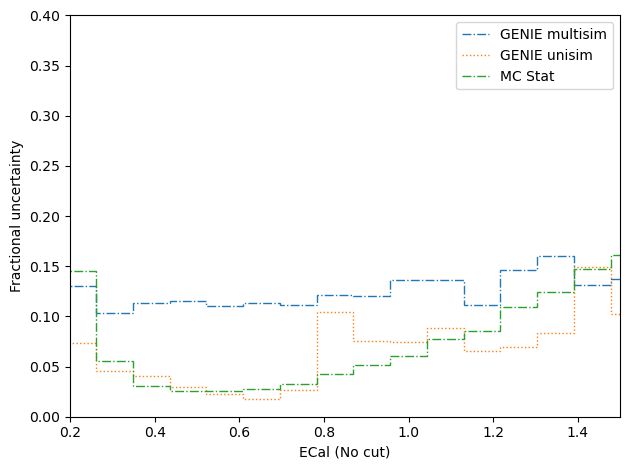


Using variable: ECal_pT04
bin counts: [  0.           0.           7.56024624  62.17995445 192.37204341
 272.54549965 266.46608518 232.83524346 192.5472012  144.37708158
  93.90812582  70.0243325   49.68936644  30.03602305  24.97165699
  18.18600771  11.67409652   7.08714288   6.69165141   1.80251393
   1.4670168    0.71318838   0.69297237]
stat fractional error: [0.         0.         0.14692448 0.05932225 0.03312895 0.02863778
 0.02758715 0.02982519 0.03555175 0.04503588 0.05558649 0.0660946
 0.08474319 0.09241722 0.11330102 0.12846863 0.13659545 0.18578543
 0.31089787 0.27835004 0.39771201 0.44916801 0.44752772]

GENIE multisim fractional error: [0.         0.         0.13115231 0.10154965 0.11097341 0.10986254
 0.10367796 0.10853697 0.10597224 0.11664877 0.10756934 0.12921015
 0.1306395  0.10206839 0.13408501 0.13357863 0.13002348 0.1101386
 0.17882362 0.11853288 0.15037856 0.2539664  0.10733089]

GENIE unisim fractional error: [0.         0.         0.07487712 0.05632654 0.044473

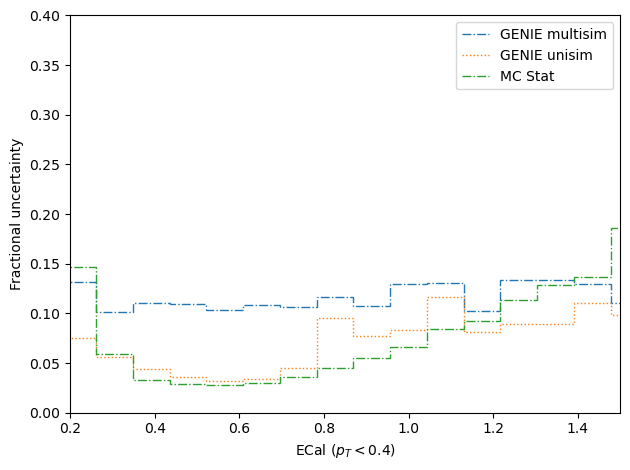


Using variable: ECal_pT03
bin counts: [  0.           0.           6.64497519  51.28392734 152.11523869
 220.74805629 218.64063045 192.04583597 162.98617599 120.60420983
  80.30229045  52.38091175  37.23606831  24.53545629  19.51480365
  15.92568784   9.71378994   5.9817277    5.38976839   1.5345338
   1.01263409   0.71318838   0.69297237]
stat fractional error: [0.         0.         0.15892087 0.06361318 0.03590774 0.03101731
 0.02960821 0.03074956 0.03729041 0.04634219 0.05586871 0.06419565
 0.08310017 0.08343555 0.1192811  0.13374022 0.12615106 0.20791481
 0.34555756 0.30273417 0.36142619 0.44916801 0.44752772]

GENIE multisim fractional error: [0.         0.         0.13200356 0.0965719  0.10425789 0.10691789
 0.10201703 0.10680702 0.10507513 0.11185812 0.10128576 0.11200072
 0.10759265 0.09858473 0.12322043 0.12709601 0.11881331 0.11483086
 0.16993238 0.12733651 0.10698255 0.2539664  0.10733089]

GENIE unisim fractional error: [0.         0.         0.05778694 0.06231286 0.05796

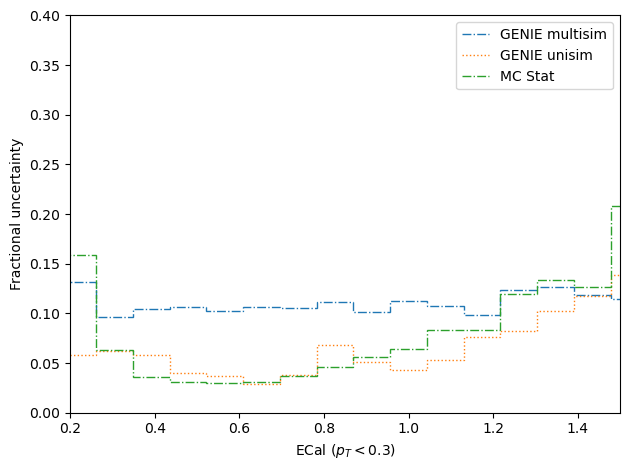


Using variable: ECal_pT02
bin counts: [  0.           0.           4.34163345  32.80097702  99.74777028
 150.64084883 151.94213258 136.72510196 113.93762127  84.76712216
  56.38761166  37.17611825  26.72334805  19.60450137  13.14913379
  10.85205567   5.50395533   5.4300172    4.67627372   0.67417582
   0.54593633   0.41665963   0.28012942]
stat fractional error: [0.         0.         0.18736685 0.07858413 0.04396042 0.03711763
 0.03456185 0.0360304  0.04314352 0.05329288 0.06336059 0.07505518
 0.09786045 0.09224185 0.14609245 0.1620422  0.16036893 0.22329888
 0.39239161 0.44735466 0.50081391 0.57800785 0.70780588]

GENIE multisim fractional error: [0.         0.         0.16630929 0.08497777 0.09639191 0.10188601
 0.10589173 0.10704024 0.10182598 0.1098294  0.1002992  0.10523458
 0.10423824 0.10508391 0.13202176 0.13972803 0.11265037 0.11943322
 0.1883796  0.11494805 0.10486948 0.14368351 0.069089  ]

GENIE unisim fractional error: [0.         0.         0.03000608 0.0601761  0.0635

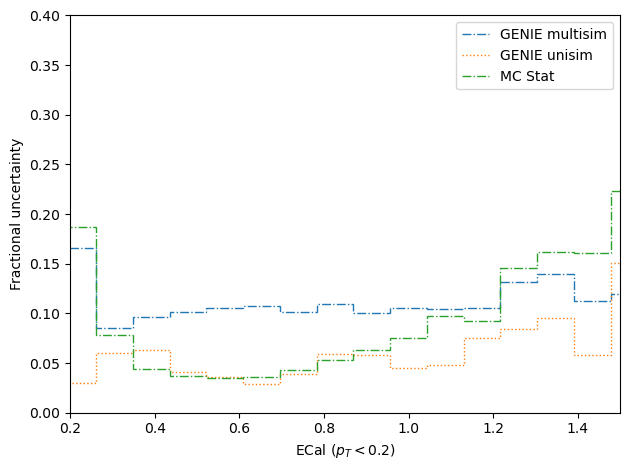

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from microfit import histogram as hist
from microfit import detsys  # unused here, but fine to keep


# --- Helper: fractional error from covariance + central values ---
def fractional_error_from_cov(cov, central):
    """
    cov: (nbins, nbins) covariance matrix
    central: (nbins,) central bin contents (same normalization as cov)
    returns: (nbins,) fractional uncertainties (sigma / central)
    """
    central = np.asarray(central)
    diag = np.diag(cov)
    frac = np.zeros_like(central, dtype=float)

    mask = central > 0
    frac[mask] = np.sqrt(diag[mask]) / central[mask]
    # bins with central == 0 stay 0 (or you could set np.nan if you prefer)
    return frac



reco_delta_pT = sel_mc_1mu1p["delta_pT"].values
sel_mc_1mu1p["delta_pT"] = reco_delta_pT

for k, df in rundata.items():
    if df is None:
        continue

    # ECal for all events
    df["ECal_all"] = sel_mc_1mu1p["Ecal"]
    df["delta_pT"] = sel_mc_1mu1p["delta_pT"]

    # ECal only for pT < 0.4
    mask = df["delta_pT"] < 0.4
    df["ECal_pT04"] = np.nan
    df.loc[mask, "ECal_pT04"] = df.loc[mask, "ECal_all"]

    # ECal only for pT < 0.3
    mask = df["delta_pT"] < 0.3
    df["ECal_pT03"] = np.nan
    df.loc[mask, "ECal_pT03"] = df.loc[mask, "ECal_all"]

    # ECal only for pT < 0.2
    mask = df["delta_pT"] < 0.2
    df["ECal_pT02"] = np.nan
    df.loc[mask, "ECal_pT02"] = df.loc[mask, "ECal_all"]


# IntegratedFlux = 1  # not needed for fractional errors

# edges = np.linspace(0.0, 1.5, 15)  # OG
edges = np.linspace(0.0, 2.0, 24)
my_vars = [
    ("ECal_all",  edges, r"ECal (No cut)"),
    ("ECal_pT04", edges, r"ECal ($p_T<0.4$)"),
    ("ECal_pT03", edges, r"ECal ($p_T<0.3$)"),
    ("ECal_pT02", edges, r"ECal ($p_T<0.2$)"),
]

for var_name, var_edges, var_tex in my_vars:
    #  Binning from Ecal new df column 
    binning = hist.Binning(
        variable=var_name,
        bin_edges=var_edges,
        label=var_name,
        variable_tex=var_tex,
    )
    print(f"\nUsing variable: {var_name}")
    
    #Build a single RunHistGenerator for this binning
    run_hist_gen = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        detvar_data=None,          # <-- no detector systematics here
        uncertainty_defaults=None,
    )

    # Stat-only total prediction (MC + EXT), no multisim or detsys
    total_prediction_stat = run_hist_gen.get_total_prediction(
        include_multisim_errors=False,
        add_precomputed_detsys=False,
    )

    bin_counts = total_prediction_stat.bin_counts
    print("bin counts:", bin_counts)

    # Stat covariance is already in the same normalization as bin_counts
    stat_cov = total_prediction_stat.covariance_matrix
    stat_error_frac = fractional_error_from_cov(stat_cov, bin_counts)
    print("stat fractional error:", stat_error_frac)
    print()

    # GENIE multisim + unisim covariance (MC only)
    #    We use the underlying mc_hist_generator from the same RunHistGenerator
    mc_hist_generator = run_hist_gen.mc_hist_generator

    # GENIE multisim covariance (weightsGenie)
    genie_cov = mc_hist_generator.calculate_multisim_uncertainties(
        multisim_weight_column="weightsGenie"
    )
    genie_error_frac = fractional_error_from_cov(genie_cov, bin_counts)
    print("GENIE multisim fractional error:", genie_error_frac)
    print()

    # GENIE unisim covariance
    genie_unisim_cov = mc_hist_generator.calculate_unisim_uncertainties()
    genie_unisim_error_frac = fractional_error_from_cov(genie_unisim_cov, bin_counts)
    print("GENIE unisim fractional error:", genie_unisim_error_frac)
    print()

    # Combine GENIE multisim + unisim in quadrature
    genie_total_error_frac = np.sqrt(
        genie_error_frac**2 + genie_unisim_error_frac**2
    )
    print("GENIE total (multisim ⊕ unisim) fractional error:", genie_total_error_frac)
    print()

    # Optionally, total (stat + GENIE) fractional uncertainty
    total_frac_error = np.sqrt(stat_error_frac**2 + genie_total_error_frac**2)
    print("Total (stat ⊕ GENIE) fractional error:", total_frac_error)
    print()

    # Fractional uncertainty plot
    fig, ax = plt.subplots()

    ax.stairs(genie_error_frac,        var_edges, label="GENIE multisim", linestyle="dashdot")
    ax.stairs(genie_unisim_error_frac, var_edges, label="GENIE unisim",   linestyle="dotted")
    #ax.stairs(genie_total_error_frac,  var_edges, label="GENIE total",    linestyle="solid")
    ax.stairs(stat_error_frac,         var_edges, label="MC Stat",        linestyle="dashdot")
    # If you want: ax.stairs(total_frac_error, var_edges, label="Total", linestyle="solid")

    ax.set_xlabel(var_tex)
    ax.set_ylabel("Fractional uncertainty")
    ax.legend(loc="best")
    ax.set_ylim(0, 0.4)
    ax.set_xlim(0.20, 1.50)

    plt.tight_layout()
    # plt.savefig(f'analysis_plots/errors/noDet_{var_name}_{len(edges)-1}bins.png',
    #             bbox_inches='tight')
    plt.show()
    plt.close()


## ABSOLUTE ERROR

/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  



Using variable: ECal_all
bin counts: [  0.           0.           7.69043224  73.37680342 236.69871797
 336.09313857 340.55814777 290.97878643 238.80564427 182.94653457
 119.9415392   88.80601208  62.42887554  36.91175152  30.77601591
  24.5341831   14.57343009  10.68639082   7.11444418   4.19911668
   1.66498927   0.71318838   0.95334438]
stat abs error: [1.68587394e-07 1.68587394e-07 1.11838822e+00 4.08898673e+00
 7.18697621e+00 8.61623610e+00 8.87517826e+00 8.11329156e+00
 7.88225794e+00 7.75273302e+00 6.17566092e+00 5.39787679e+00
 4.81924721e+00 3.17216714e+00 3.37306239e+00 3.05822095e+00
 2.14996108e+00 1.72828604e+00 2.09235475e+00 1.37925253e+00
 6.02211180e-01 3.20341405e-01 3.60657592e-01]

GENIE multisim abs error: [ 0.          0.          1.00438295  7.59669696 26.91214617 38.76178922
 37.49168201 33.06529157 26.58415171 22.146765   14.39508338 12.09431139
  8.49443242  4.12792131  4.49651039  3.92444722  1.91515142  1.47018955
  1.24299132  1.42385434  0.23057788  0.181

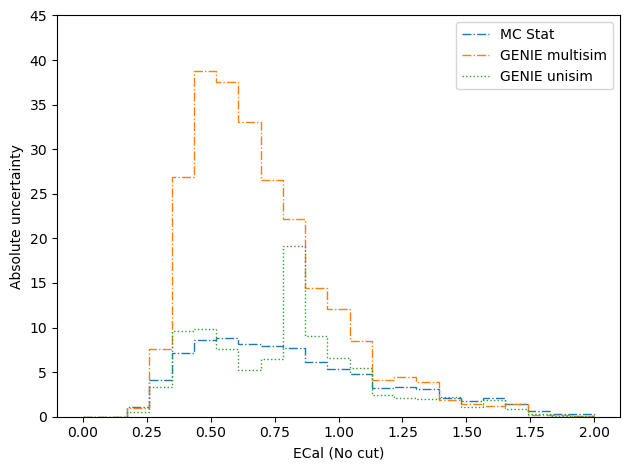


Using variable: ECal_pT04
bin counts: [  0.           0.           7.56024624  62.17995445 192.37204341
 272.54549965 266.46608518 232.83524346 192.5472012  144.37708158
  93.90812582  70.0243325   49.68936644  30.03602305  24.97165699
  18.18600771  11.67409652   7.08714288   6.69165141   1.80251393
   1.4670168    0.71318838   0.69297237]
stat abs error: [1.68587394e-07 1.68587394e-07 1.11078522e+00 3.68865498e+00
 6.37308425e+00 7.80509822e+00 7.35103950e+00 6.94435638e+00
 6.84539024e+00 6.50214869e+00 5.22002270e+00 4.62823010e+00
 4.21083531e+00 2.77584579e+00 2.82931417e+00 2.33633155e+00
 1.59462846e+00 1.31668790e+00 2.08042019e+00 5.01729827e-01
 5.83450201e-01 3.20341405e-01 3.10124343e-01]

GENIE multisim abs error: [ 0.          0.          0.99154372  6.31435244 21.34818195 29.94254211
 27.62666088 25.27123279 20.4046586  16.84140835 10.101635    9.04785448
  6.49139415  3.06572846  3.34832476  2.42926207  1.51790665  0.78056798
  1.19662531  0.21365717  0.22060787  0.18

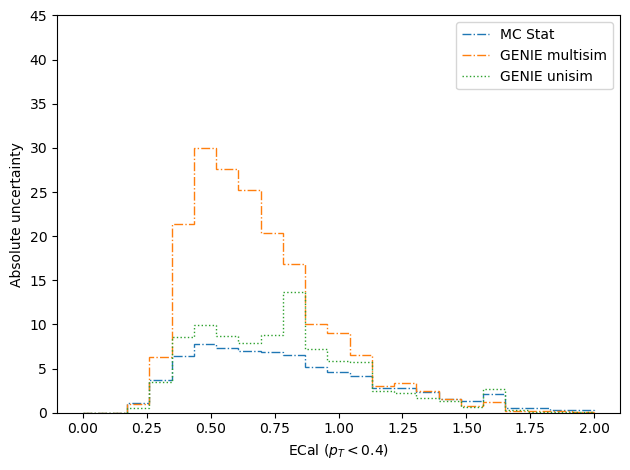


Using variable: ECal_pT03
bin counts: [  0.           0.           6.64497519  51.28392734 152.11523869
 220.74805629 218.64063045 192.04583597 162.98617599 120.60420983
  80.30229045  52.38091175  37.23606831  24.53545629  19.51480365
  15.92568784   9.71378994   5.9817277    5.38976839   1.5345338
   1.01263409   0.71318838   0.69297237]
stat abs error: [1.19209290e-07 1.19209290e-07 1.05602523e+00 3.26233348e+00
 5.46211485e+00 6.84701040e+00 6.47355769e+00 5.90532528e+00
 6.07782172e+00 5.58906365e+00 4.48638537e+00 3.36262672e+00
 3.09432379e+00 2.04712920e+00 2.32774733e+00 2.12990505e+00
 1.22540492e+00 1.24368976e+00 1.86247523e+00 4.64555810e-01
 3.65992482e-01 3.20341405e-01 3.10124343e-01]

GENIE multisim abs error: [ 0.          0.          0.87716038  4.95258639 15.85921444 23.60191653
 22.30506839 20.51184251 17.12579313 13.4905603   8.13347817  5.8666996
  4.00632732  2.41882146  2.40462245  2.02409136  1.15412756  0.68688693
  0.91589619  0.19540219  0.10833417  0.1811

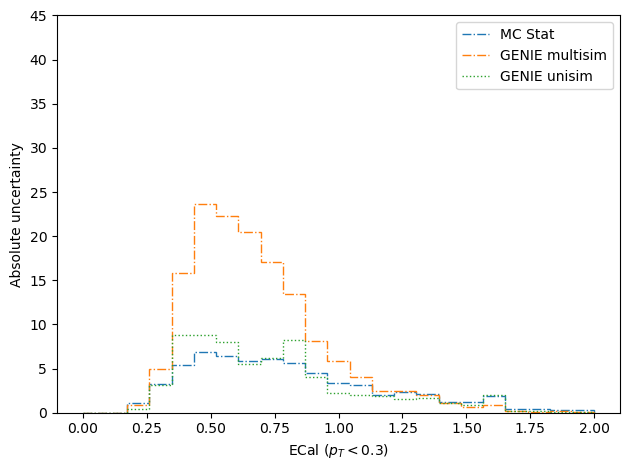


Using variable: ECal_pT02
bin counts: [  0.           0.           4.34163345  32.80097702  99.74777028
 150.64084883 151.94213258 136.72510196 113.93762127  84.76712216
  56.38761166  37.17611825  26.72334805  19.60450137  13.14913379
  10.85205567   5.50395533   5.4300172    4.67627372   0.67417582
   0.54593633   0.41665963   0.28012942]
stat abs error: [8.42936970e-08 8.42936970e-08 8.13478172e-01 2.57763627e+00
 4.38495360e+00 5.59143135e+00 5.25140080e+00 4.92626073e+00
 4.91567020e+00 4.51748444e+00 3.57275223e+00 2.79026042e+00
 2.61515876e+00 1.80835548e+00 1.92098922e+00 1.75849099e+00
 8.82663444e-01 1.21251675e+00 1.83493058e+00 3.01595695e-01
 2.73412508e-01 2.40832538e-01 1.98277249e-01]

GENIE multisim abs error: [ 0.          0.          0.72205396  2.78735372  9.61487798 15.34819575
 16.08941505 14.63508826 11.60181037  9.30992208  5.65563206  3.91221324
  2.78559465  2.06011773  1.73597177  1.51633639  0.62002262  0.64852443
  0.88091458  0.07749519  0.05725206  0.05

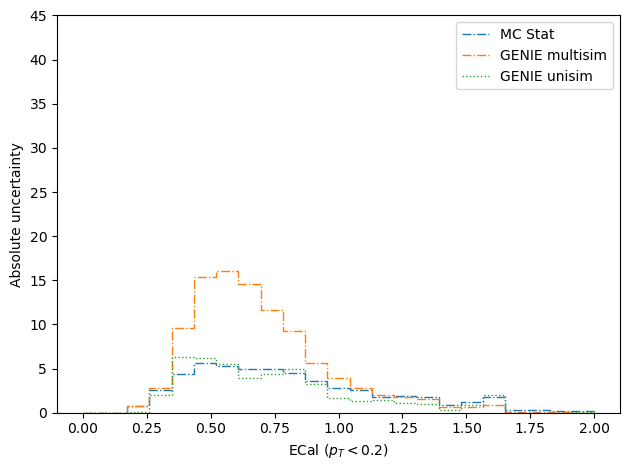

In [20]:
import numpy as np
import matplotlib.pyplot as plt

from microfit import histogram as hist
from microfit import detsys  # unused but fine

reco_delta_pT = sel_mc_1mu1p["delta_pT"].values
sel_mc_1mu1p["delta_pT"] = reco_delta_pT

for k, df in rundata.items():
    if df is None:
        continue

    # ECal for all events
    df["ECal_all"] = sel_mc_1mu1p["Ecal"]
    df["delta_pT"] = sel_mc_1mu1p["delta_pT"]

    # ECal only for pT < 0.4
    mask = df["delta_pT"] < 0.4
    df["ECal_pT04"] = np.nan
    df.loc[mask, "ECal_pT04"] = df.loc[mask, "ECal_all"]

    # ECal only for pT < 0.3
    mask = df["delta_pT"] < 0.3
    df["ECal_pT03"] = np.nan
    df.loc[mask, "ECal_pT03"] = df.loc[mask, "ECal_all"]

    # ECal only for pT < 0.2
    mask = df["delta_pT"] < 0.2
    df["ECal_pT02"] = np.nan
    df.loc[mask, "ECal_pT02"] = df.loc[mask, "ECal_all"]


edges = np.linspace(0.0, 2.0, 24)
my_vars = [
    ("ECal_all",  edges, r"ECal (No cut)"),
    ("ECal_pT04", edges, r"ECal ($p_T<0.4$)"),
    ("ECal_pT03", edges, r"ECal ($p_T<0.3$)"),
    ("ECal_pT02", edges, r"ECal ($p_T<0.2$)"),
]

for var_name, var_edges, var_tex in my_vars:
    #  Binning from Ecal new df column 
    binning = hist.Binning(
        variable=var_name,
        bin_edges=var_edges,
        label=var_name,
        variable_tex=var_tex,
    )
    print(f"\nUsing variable: {var_name}")
    
    #  Build a single RunHistGenerator for this binning
    run_hist_gen = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        detvar_data=None,          # <-- no detector systematics here
        uncertainty_defaults=None,
    )

    # Stat-only total prediction (MC + EXT), no multisim or detsys
    total_prediction_stat = run_hist_gen.get_total_prediction(
        include_multisim_errors=False,
        add_precomputed_detsys=False,
    )

    bin_counts = total_prediction_stat.bin_counts
    print("bin counts:", bin_counts)

    # Stat covariance is already in the same normalization as bin_counts
    stat_cov = total_prediction_stat.covariance_matrix
    stat_sigma = np.sqrt(np.diag(stat_cov))
    print("stat abs error:", stat_sigma)
    print()

    # GENIE multisim + unisim covariance (MC only)
    mc_hist_generator = run_hist_gen.mc_hist_generator

    # GENIE multisim covariance (weightsGenie)
    genie_cov = mc_hist_generator.calculate_multisim_uncertainties(
        multisim_weight_column="weightsGenie"
    )
    genie_sigma = np.sqrt(np.diag(genie_cov))
    print("GENIE multisim abs error:", genie_sigma)
    print()

    # GENIE unisim covariance
    genie_unisim_cov = mc_hist_generator.calculate_unisim_uncertainties()
    genie_unisim_sigma = np.sqrt(np.diag(genie_unisim_cov))
    print("GENIE unisim abs error:", genie_unisim_sigma)
    print()

    # Combine GENIE multisim + unisim in quadrature (per bin)
    genie_total_sigma = np.sqrt(genie_sigma**2 + genie_unisim_sigma**2)
    print("GENIE total (multisim ⊕ unisim) abs error:", genie_total_sigma)
    print()

    # Optionally, total (stat + GENIE) absolute uncertainty per bin
    total_sigma = np.sqrt(stat_sigma**2 + genie_total_sigma**2)
    print("Total (stat ⊕ GENIE) abs error:", total_sigma)
    print()

    # Absolute uncertainty plot
    fig, ax = plt.subplots()

    ax.stairs(stat_sigma,         var_edges, label="MC Stat",        linestyle="dashdot")
    ax.stairs(genie_sigma,        var_edges, label="GENIE multisim", linestyle="dashdot")
    ax.stairs(genie_unisim_sigma, var_edges, label="GENIE unisim",   linestyle="dotted")
    #ax.stairs(genie_total_sigma,  var_edges, label="GENIE total",    linestyle="solid")
    #ax.stairs(total_sigma,        var_edges, label="Total",          linestyle="solid")

    ax.set_xlabel(var_tex)
    ax.set_ylabel("Absolute uncertainty")
    ax.legend(loc="best")
    ax.set_ylim(0, 45)
    plt.tight_layout()
    plt.show()
    plt.close()


## SUB PROCESS -> ECAL

In [25]:
# from microfit.statistics import covariance 

# # Get total cov + per-knob histograms
# unisim_cov_total, unisim_hist_dict = mc_hist_generator.calculate_unisim_uncertainties(
#     return_histograms=True,
#     skip_covariance=False,   # we still want total
# )

# # Central value histogram for this generator (same selection/binning)
# central_hist = mc_hist_generator._histogram_multi_channel(mc_hist_generator.dataframe)
# cv_counts = central_hist.bin_counts

# unisim_errors_per_knob = {}

# for knob, observations in unisim_hist_dict.items():
#     # observations shape: (n_universes, n_bins)
#     cov_knob = covariance(
#         observations,
#         cv_counts,
#         allow_approximation=True,
#         tolerance=1e-8,
#         debug_name=knob,
#     ) / IntegratedFlux**2
#     err_knob = np.sqrt(np.diag(cov_knob)) / safe_counts
#     unisim_errors_per_knob[knob] = err_knob


In [26]:
# fig, ax = plt.subplots()

# ax.stairs(stat_error, var_edges, label='MC Stat')

# ax.stairs(genie_error, var_edges, label='GENIE multisim')

# #dominant knobs
# for knob in ["knobRPA", "knobCCMEC", "knobAxFFCCQE","knobAxFFCCQE","knobDecayAngMEC","knobThetaDelta2Npi",]:
#     if knob in unisim_errors_per_knob:
#         ax.stairs(unisim_errors_per_knob[knob], var_edges, label=f'{knob}', linestyle='dashdot')

# ax.set_xlabel(var_tex)
# ax.set_ylabel('Fractional uncertainty')
# ax.legend(loc="best")
# ax.set_ylim(0, 0.4)
# ax.set_xlim(0.20, 1.50)
# plt.tight_layout()
# plt.show()
# plt.close()


### Fractional


Using variable: ECal_all
bin counts: [  0.           0.           7.69043224  73.37680342 236.69871797
 336.09313857 340.55814777 290.97878643 238.80564427 182.94653457
 119.9415392   88.80601208  62.42887554  36.91175152  30.77601591
  24.5341831   14.57343009  10.68639082   7.11444418   4.19911668
   1.66498927   0.71318838   0.95334438]
stat error: [       nan        nan 0.14542592 0.05572588 0.03036339 0.02563645
 0.02606068 0.02788276 0.033007   0.04237704 0.05148893 0.06078279
 0.0771958  0.08593922 0.10960036 0.12465143 0.14752608 0.16172776
 0.29409954 0.32846254 0.36169073 0.44916801 0.37830778]

GENIE multisim error: [       nan        nan 0.13060163 0.10352995 0.1136979  0.1153305
 0.11008893 0.11363472 0.11132129 0.12105594 0.1200175  0.13618798
 0.13606576 0.11183217 0.14610437 0.15995834 0.13141391 0.13757587
 0.17471376 0.33908425 0.13848611 0.2539664  0.14082578]

GENIE unisim total error: [       nan        nan 0.07360958 0.04546177 0.04051186 0.02921773
 0.02220359 0

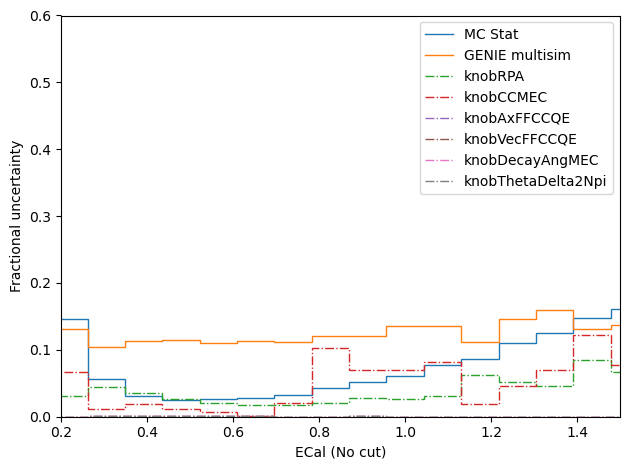


Using variable: ECal_pT04
bin counts: [  0.           0.           7.56024624  62.17995445 192.37204341
 272.54549965 266.46608518 232.83524346 192.5472012  144.37708158
  93.90812582  70.0243325   49.68936644  30.03602305  24.97165699
  18.18600771  11.67409652   7.08714288   6.69165141   1.80251393
   1.4670168    0.71318838   0.69297237]
stat error: [       nan        nan 0.14692448 0.05932225 0.03312895 0.02863778
 0.02758715 0.02982519 0.03555175 0.04503588 0.05558649 0.0660946
 0.08474319 0.09241722 0.11330102 0.12846863 0.13659545 0.18578543
 0.31089787 0.27835004 0.39771201 0.44916801 0.44752772]

GENIE multisim error: [       nan        nan 0.13115231 0.10154965 0.11097341 0.10986254
 0.10367796 0.10853697 0.10597224 0.11664877 0.10756934 0.12921015
 0.1306395  0.10206839 0.13408501 0.13357863 0.13002348 0.1101386
 0.17882362 0.11853288 0.15037856 0.2539664  0.10733089]

GENIE unisim total error: [       nan        nan 0.07487712 0.05632654 0.04447394 0.03630715
 0.0324451  0

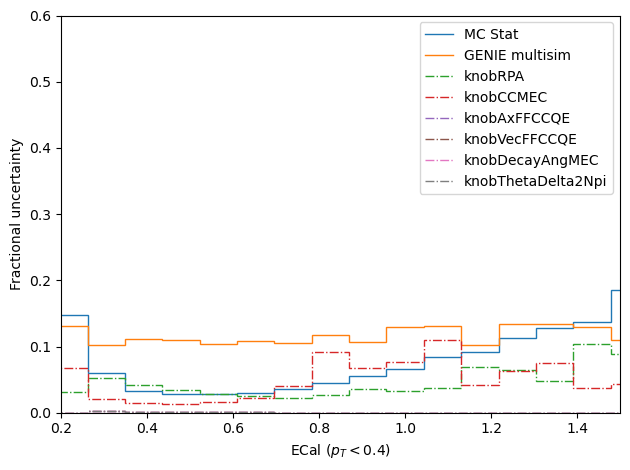


Using variable: ECal_pT03
bin counts: [  0.           0.           6.64497519  51.28392734 152.11523869
 220.74805629 218.64063045 192.04583597 162.98617599 120.60420983
  80.30229045  52.38091175  37.23606831  24.53545629  19.51480365
  15.92568784   9.71378994   5.9817277    5.38976839   1.5345338
   1.01263409   0.71318838   0.69297237]
stat error: [       nan        nan 0.15892087 0.06361318 0.03590774 0.03101731
 0.02960821 0.03074956 0.03729041 0.04634219 0.05586871 0.06419565
 0.08310017 0.08343555 0.1192811  0.13374022 0.12615106 0.20791481
 0.34555756 0.30273417 0.36142619 0.44916801 0.44752772]

GENIE multisim error: [       nan        nan 0.13200356 0.0965719  0.10425789 0.10691789
 0.10201703 0.10680702 0.10507513 0.11185812 0.10128576 0.11200072
 0.10759265 0.09858473 0.12322043 0.12709601 0.11881331 0.11483086
 0.16993238 0.12733651 0.10698255 0.2539664  0.10733089]

GENIE unisim total error: [       nan        nan 0.05778694 0.06231286 0.05796085 0.03988653
 0.0368087  

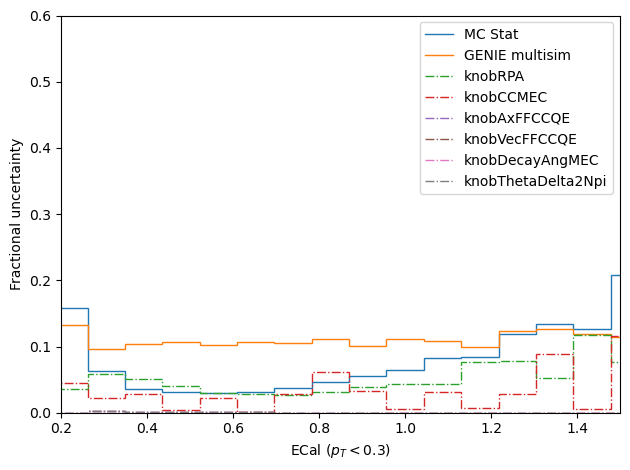


Using variable: ECal_pT02
bin counts: [  0.           0.           4.34163345  32.80097702  99.74777028
 150.64084883 151.94213258 136.72510196 113.93762127  84.76712216
  56.38761166  37.17611825  26.72334805  19.60450137  13.14913379
  10.85205567   5.50395533   5.4300172    4.67627372   0.67417582
   0.54593633   0.41665963   0.28012942]
stat error: [       nan        nan 0.18736685 0.07858413 0.04396042 0.03711763
 0.03456185 0.0360304  0.04314352 0.05329288 0.06336059 0.07505518
 0.09786045 0.09224185 0.14609245 0.1620422  0.16036893 0.22329888
 0.39239161 0.44735466 0.50081391 0.57800785 0.70780588]

GENIE multisim error: [       nan        nan 0.16630929 0.08497777 0.09639191 0.10188601
 0.10589173 0.10704024 0.10182598 0.1098294  0.1002992  0.10523458
 0.10423824 0.10508391 0.13202176 0.13972803 0.11265037 0.11943322
 0.1883796  0.11494805 0.10486948 0.14368351 0.069089  ]

GENIE unisim total error: [       nan        nan 0.03000608 0.0601761  0.06356043 0.04088356
 0.03644159

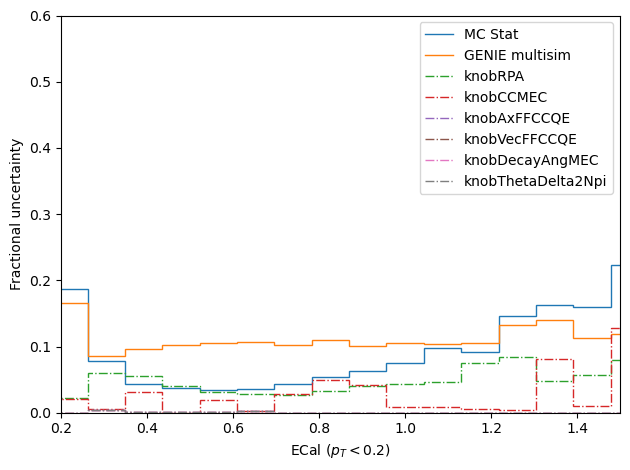

In [27]:
from microfit.statistics import covariance


edges = np.linspace(0.0, 1.0, 12)
# my_vars1 = [
#     ("delta_pT",  edges, r"delta_pT (No cut)"),
    
# ]

for var_name, var_edges, var_tex in my_vars:
    # Binning from Ecal-like df column 
    binning = hist.Binning(
        variable=var_name,
        bin_edges=var_edges,
        label=var_name,
        variable_tex=var_tex,
    )
    print(f"\nUsing variable: {var_name}")

    
    # MC stat only
    signal_generator_stat = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        detvar_data=None,
        uncertainty_defaults=None,
    )

    total_prediction_stat = signal_generator_stat.get_total_prediction(
        include_multisim_errors=False,
        add_precomputed_detsys=False,
    )

    bin_counts = total_prediction_stat.bin_counts
    print("bin counts:", bin_counts)

    # Define this (if we want flux normalization) or set to 1
    IntegratedFlux = 1.0

    flux_norm_total_prediction_stat = total_prediction_stat / IntegratedFlux
    stat_cov = flux_norm_total_prediction_stat.covariance_matrix

    # Protect against division by zero
    safe_counts = bin_counts.astype(float).copy()
    safe_counts[safe_counts == 0] = np.nan

    stat_error = np.sqrt(np.diag(stat_cov)) / safe_counts
    print("stat error:", stat_error)
    print()

    # Multisim: GENIE total
    signal_generator_multisim = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
        detvar_data=None,
    )

    mc_hist_generator = signal_generator_multisim.mc_hist_generator

    genie_cov = (
        mc_hist_generator.calculate_multisim_uncertainties(
            multisim_weight_column="weightsGenie"
        )
        / IntegratedFlux**2
    )
    genie_error = np.sqrt(np.diag(genie_cov)) / safe_counts
    print("GENIE multisim error:", genie_error)
    print()

    
    #Unisim: total + per-knob
    
    unisim_cov_total, unisim_hist_dict = mc_hist_generator.calculate_unisim_uncertainties(
        return_histograms=True,
        skip_covariance=False,   # we also want the total covariance
    )

    # Total GENIE unisim fractional error
    genie_unisim_error_total = np.sqrt(np.diag(unisim_cov_total)) / safe_counts
    print("GENIE unisim total error:", genie_unisim_error_total)
    print()

    # Central value (same binning/selection) used for per-knob covariances
    central_hist = mc_hist_generator._histogram_multi_channel(mc_hist_generator.dataframe)
    cv_counts = central_hist.bin_counts

    unisim_errors_per_knob = {}
    for knob, observations in unisim_hist_dict.items():
        # observations shape: (n_universes, n_bins)
        cov_knob = (
            covariance(
                observations,
                cv_counts,
                allow_approximation=True,
                tolerance=1e-8,
                debug_name=knob,
            )
            / IntegratedFlux**2
        )
        err_knob = np.sqrt(np.diag(cov_knob)) / safe_counts
        unisim_errors_per_knob[knob] = err_knob
        print(f"{knob} unisim error:", err_knob)

    # Plot: stat, GENIE multisim (total), all unisim knobs, unisim total
    fig, ax = plt.subplots()

    ax.stairs(stat_error, var_edges, label="MC Stat")

    ax.stairs(
        genie_error,
        var_edges,
        label="GENIE multisim",
    )

    # Plot every knob in unisim_errors_per_knob
    for knob, err_knob in unisim_errors_per_knob.items():
        ax.stairs(
            err_knob,
            var_edges,
            label=knob,
            linestyle="dashdot",
        )

    # plot the *total* unisim uncertainty
#     ax.stairs(
#         genie_unisim_error_total,
#         var_edges,
#         label="GENIE unisim (total)",
#         linestyle="dashed",
#     )

    ax.set_xlabel(var_tex)
    ax.set_ylabel("Fractional uncertainty")
    ax.legend(loc="best")
    ax.set_ylim(0, 0.6)
    ax.set_xlim(0.20, 1.50)
    #ax.set_xlim(0.0, 1.0) #delta_pT
    plt.tight_layout()
    plt.show()
    plt.close()



Using variable: ECal_all
bin counts: [  0.           0.           7.69043224  73.37680342 236.69871797
 336.09313857 340.55814777 290.97878643 238.80564427 182.94653457
 119.9415392   88.80601208  62.42887554  36.91175152  30.77601591
  24.5341831   14.57343009  10.68639082   7.11444418   4.19911668
   1.66498927   0.71318838   0.95334438]
MC stat fractional error: [       nan        nan 0.14542592 0.05572588 0.03036339 0.02563645
 0.02606068 0.02788276 0.033007   0.04237704 0.05148893 0.06078279
 0.0771958  0.08593922 0.10960036 0.12465143 0.14752608 0.16172776
 0.29409954 0.32846254 0.36169073 0.44916801 0.37830778]
GENIE multisim fractional error: [       nan        nan 0.13060163 0.10352995 0.1136979  0.1153305
 0.11008893 0.11363472 0.11132129 0.12105594 0.1200175  0.13618798
 0.13606576 0.11183217 0.14610437 0.15995834 0.13141391 0.13757587
 0.17471376 0.33908425 0.13848611 0.2539664  0.14082578]
GENIE unisim total fractional error: [       nan        nan 0.07360958 0.04546177 0

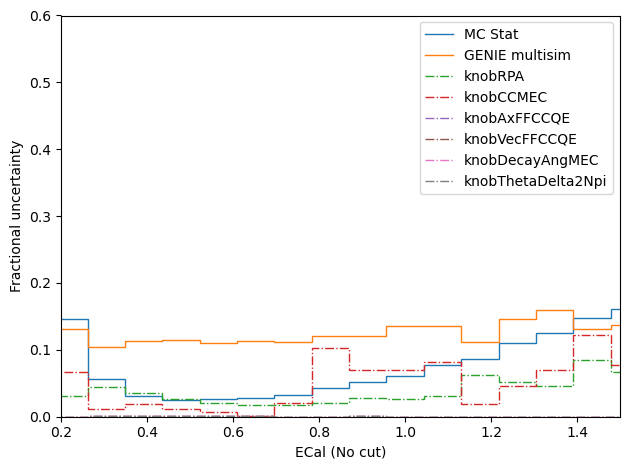


Using variable: ECal_pT04
bin counts: [  0.           0.           7.56024624  62.17995445 192.37204341
 272.54549965 266.46608518 232.83524346 192.5472012  144.37708158
  93.90812582  70.0243325   49.68936644  30.03602305  24.97165699
  18.18600771  11.67409652   7.08714288   6.69165141   1.80251393
   1.4670168    0.71318838   0.69297237]
MC stat fractional error: [       nan        nan 0.14692448 0.05932225 0.03312895 0.02863778
 0.02758715 0.02982519 0.03555175 0.04503588 0.05558649 0.0660946
 0.08474319 0.09241722 0.11330102 0.12846863 0.13659545 0.18578543
 0.31089787 0.27835004 0.39771201 0.44916801 0.44752772]
GENIE multisim fractional error: [       nan        nan 0.13115231 0.10154965 0.11097341 0.10986254
 0.10367796 0.10853697 0.10597224 0.11664877 0.10756934 0.12921015
 0.1306395  0.10206839 0.13408501 0.13357863 0.13002348 0.1101386
 0.17882362 0.11853288 0.15037856 0.2539664  0.10733089]
GENIE unisim total fractional error: [       nan        nan 0.07487712 0.05632654 0

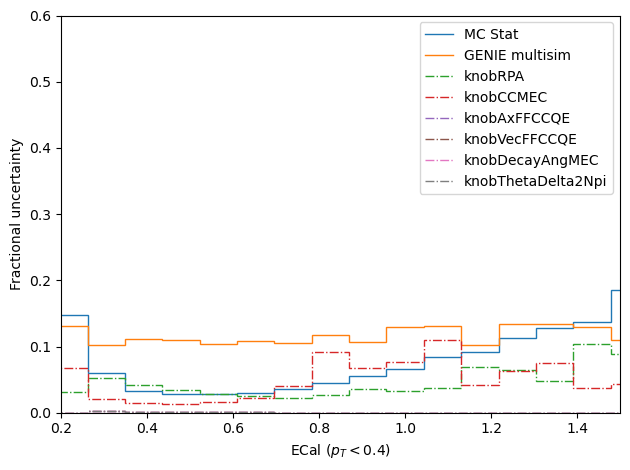


Using variable: ECal_pT03
bin counts: [  0.           0.           6.64497519  51.28392734 152.11523869
 220.74805629 218.64063045 192.04583597 162.98617599 120.60420983
  80.30229045  52.38091175  37.23606831  24.53545629  19.51480365
  15.92568784   9.71378994   5.9817277    5.38976839   1.5345338
   1.01263409   0.71318838   0.69297237]
MC stat fractional error: [       nan        nan 0.15892087 0.06361318 0.03590774 0.03101731
 0.02960821 0.03074956 0.03729041 0.04634219 0.05586871 0.06419565
 0.08310017 0.08343555 0.1192811  0.13374022 0.12615106 0.20791481
 0.34555756 0.30273417 0.36142619 0.44916801 0.44752772]
GENIE multisim fractional error: [       nan        nan 0.13200356 0.0965719  0.10425789 0.10691789
 0.10201703 0.10680702 0.10507513 0.11185812 0.10128576 0.11200072
 0.10759265 0.09858473 0.12322043 0.12709601 0.11881331 0.11483086
 0.16993238 0.12733651 0.10698255 0.2539664  0.10733089]
GENIE unisim total fractional error: [       nan        nan 0.05778694 0.06231286 

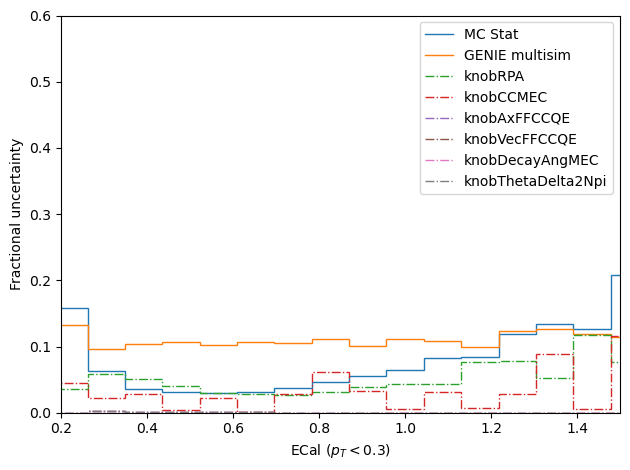


Using variable: ECal_pT02
bin counts: [  0.           0.           4.34163345  32.80097702  99.74777028
 150.64084883 151.94213258 136.72510196 113.93762127  84.76712216
  56.38761166  37.17611825  26.72334805  19.60450137  13.14913379
  10.85205567   5.50395533   5.4300172    4.67627372   0.67417582
   0.54593633   0.41665963   0.28012942]
MC stat fractional error: [       nan        nan 0.18736685 0.07858413 0.04396042 0.03711763
 0.03456185 0.0360304  0.04314352 0.05329288 0.06336059 0.07505518
 0.09786045 0.09224185 0.14609245 0.1620422  0.16036893 0.22329888
 0.39239161 0.44735466 0.50081391 0.57800785 0.70780588]
GENIE multisim fractional error: [       nan        nan 0.16630929 0.08497777 0.09639191 0.10188601
 0.10589173 0.10704024 0.10182598 0.1098294  0.1002992  0.10523458
 0.10423824 0.10508391 0.13202176 0.13972803 0.11265037 0.11943322
 0.1883796  0.11494805 0.10486948 0.14368351 0.069089  ]
GENIE unisim total fractional error: [       nan        nan 0.03000608 0.0601761 

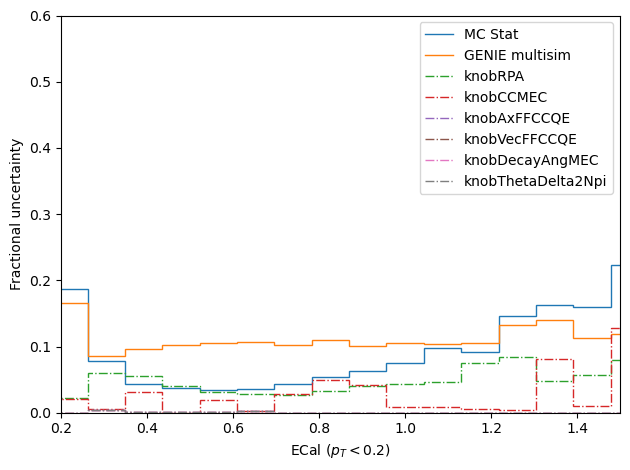

In [30]:
from microfit.statistics import covariance

edges = np.linspace(0.0, 1.0, 12)  # ECal edges 

for var_name, var_edges, var_tex in my_vars:
    binning = hist.Binning(
        variable=var_name,
        bin_edges=var_edges,
        label=var_name,
        variable_tex=var_tex,
    )
    print(f"\nUsing variable: {var_name}")

    # -----------------------
    # 1) Stat-only prediction
    # -----------------------
    signal_generator_stat = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        detvar_data=None,
        uncertainty_defaults=None,
    )

    total_prediction_stat = signal_generator_stat.get_total_prediction(
        include_multisim_errors=False,
        add_precomputed_detsys=False,
    )

    bin_counts = total_prediction_stat.bin_counts
    print("bin counts:", bin_counts)

    IntegratedFlux = 1.0

    flux_norm_total_prediction_stat = total_prediction_stat / IntegratedFlux
    stat_cov = flux_norm_total_prediction_stat.covariance_matrix

    safe_counts = bin_counts.astype(float).copy()
    safe_counts[safe_counts == 0] = np.nan

    stat_error_frac = np.sqrt(np.diag(stat_cov)) / safe_counts
    print("MC stat fractional error:", stat_error_frac)

    # -----------------------
    # 2) Multisim: GENIE
    # -----------------------
    signal_generator_multisim = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
        detvar_data=None,
    )

    mc_hist_generator = signal_generator_multisim.mc_hist_generator

    genie_cov = mc_hist_generator.calculate_multisim_uncertainties(
        multisim_weight_column="weightsGenie"
    ) / IntegratedFlux**2

    genie_error_frac = np.sqrt(np.diag(genie_cov)) / safe_counts
    print("GENIE multisim fractional error:", genie_error_frac)

    # -----------------------
    # 3) Unisim: total + per knob
    # -----------------------
    unisim_cov_total, unisim_hist_dict = mc_hist_generator.calculate_unisim_uncertainties(
        return_histograms=True,
        skip_covariance=False,
    )

    genie_unisim_total_frac = np.sqrt(np.diag(unisim_cov_total)) / safe_counts
    print("GENIE unisim total fractional error:", genie_unisim_total_frac)

    central_hist = mc_hist_generator._histogram_multi_channel(mc_hist_generator.dataframe)
    cv_counts = central_hist.bin_counts

    unisim_errors_per_knob = {}
    for knob, observations in unisim_hist_dict.items():
        cov_knob = covariance(
            observations,
            cv_counts,
            allow_approximation=True,
            tolerance=1e-8,
            debug_name=knob,
        ) / IntegratedFlux**2
        err_knob_frac = np.sqrt(np.diag(cov_knob)) / safe_counts
        unisim_errors_per_knob[knob] = err_knob_frac
        print(f"{knob} unisim fractional error:", err_knob_frac)

    # -----------------------
    # 4) Plot fractional uncertainties
    # -----------------------
    fig, ax = plt.subplots()

    ax.stairs(stat_error_frac, var_edges, label="MC Stat")
    ax.stairs(genie_error_frac, var_edges, label="GENIE multisim")

    # Either all knobs:
    for knob, err_knob_frac in unisim_errors_per_knob.items():
        ax.stairs(err_knob_frac, var_edges, label=knob, linestyle="dashdot")

    # or only dominant ones:
    # for knob in ["knobRPA", "knobCCMEC", "knobAxFFCCQE",
    #              "knobVecFFCCQE", "knobDecayAngMEC", "knobThetaDelta2Npi"]:
    #     if knob in unisim_errors_per_knob:
    #         ax.stairs(unisim_errors_per_knob[knob], var_edges,
    #                   label=knob, linestyle="dashdot")

    # If you want the total unisim as well:
    # ax.stairs(genie_unisim_total_frac, var_edges,
    #           label="GENIE unisim (total)", linestyle="dashed")

    ax.set_xlabel(var_tex)
    ax.set_ylabel("Fractional uncertainty")
    ax.legend(loc="best")
    ax.set_ylim(0, 0.6)
    ax.set_xlim(0.20, 1.50)  # or 0–1 for δpT
    plt.tight_layout()
    plt.show()
    plt.close()


### ABSOLUTE


Using variable: ECal_all
bin counts: [  0.           0.           7.69043224  73.37680342 236.69871797
 336.09313857 340.55814777 290.97878643 238.80564427 182.94653457
 119.9415392   88.80601208  62.42887554  36.91175152  30.77601591
  24.5341831   14.57343009  10.68639082   7.11444418   4.19911668
   1.66498927   0.71318838   0.95334438]
MC stat absolute error: [1.68587394e-07 1.68587394e-07 1.11838822e+00 4.08898673e+00
 7.18697621e+00 8.61623610e+00 8.87517826e+00 8.11329156e+00
 7.88225794e+00 7.75273302e+00 6.17566092e+00 5.39787679e+00
 4.81924721e+00 3.17216714e+00 3.37306239e+00 3.05822095e+00
 2.14996108e+00 1.72828604e+00 2.09235475e+00 1.37925253e+00
 6.02211180e-01 3.20341405e-01 3.60657592e-01]

GENIE multisim absolute error: [ 0.          0.          1.00438295  7.59669696 26.91214617 38.76178922
 37.49168201 33.06529157 26.58415171 22.146765   14.39508338 12.09431139
  8.49443242  4.12792131  4.49651039  3.92444722  1.91515142  1.47018955
  1.24299132  1.42385434  0.23

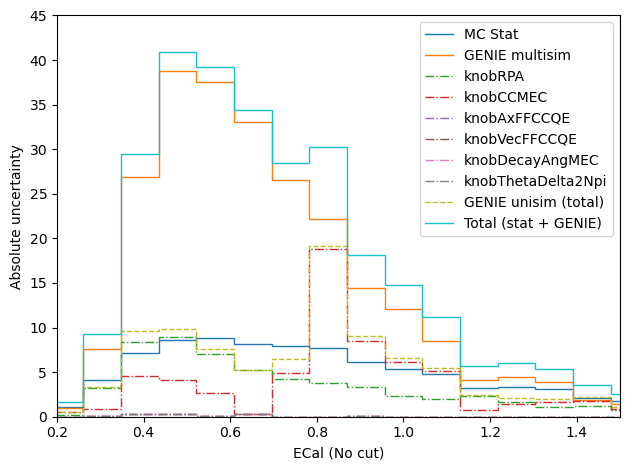


Using variable: ECal_pT04
bin counts: [  0.           0.           7.56024624  62.17995445 192.37204341
 272.54549965 266.46608518 232.83524346 192.5472012  144.37708158
  93.90812582  70.0243325   49.68936644  30.03602305  24.97165699
  18.18600771  11.67409652   7.08714288   6.69165141   1.80251393
   1.4670168    0.71318838   0.69297237]
MC stat absolute error: [1.68587394e-07 1.68587394e-07 1.11078522e+00 3.68865498e+00
 6.37308425e+00 7.80509822e+00 7.35103950e+00 6.94435638e+00
 6.84539024e+00 6.50214869e+00 5.22002270e+00 4.62823010e+00
 4.21083531e+00 2.77584579e+00 2.82931417e+00 2.33633155e+00
 1.59462846e+00 1.31668790e+00 2.08042019e+00 5.01729827e-01
 5.83450201e-01 3.20341405e-01 3.10124343e-01]

GENIE multisim absolute error: [ 0.          0.          0.99154372  6.31435244 21.34818195 29.94254211
 27.62666088 25.27123279 20.4046586  16.84140835 10.101635    9.04785448
  6.49139415  3.06572846  3.34832476  2.42926207  1.51790665  0.78056798
  1.19662531  0.21365717  0.2

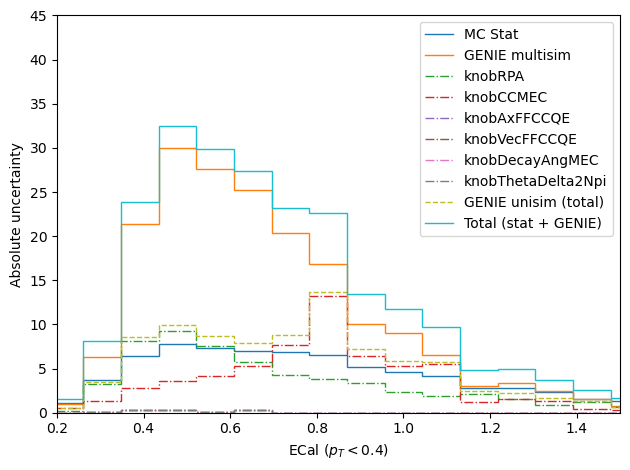


Using variable: ECal_pT03
bin counts: [  0.           0.           6.64497519  51.28392734 152.11523869
 220.74805629 218.64063045 192.04583597 162.98617599 120.60420983
  80.30229045  52.38091175  37.23606831  24.53545629  19.51480365
  15.92568784   9.71378994   5.9817277    5.38976839   1.5345338
   1.01263409   0.71318838   0.69297237]
MC stat absolute error: [1.19209290e-07 1.19209290e-07 1.05602523e+00 3.26233348e+00
 5.46211485e+00 6.84701040e+00 6.47355769e+00 5.90532528e+00
 6.07782172e+00 5.58906365e+00 4.48638537e+00 3.36262672e+00
 3.09432379e+00 2.04712920e+00 2.32774733e+00 2.12990505e+00
 1.22540492e+00 1.24368976e+00 1.86247523e+00 4.64555810e-01
 3.65992482e-01 3.20341405e-01 3.10124343e-01]

GENIE multisim absolute error: [ 0.          0.          0.87716038  4.95258639 15.85921444 23.60191653
 22.30506839 20.51184251 17.12579313 13.4905603   8.13347817  5.8666996
  4.00632732  2.41882146  2.40462245  2.02409136  1.15412756  0.68688693
  0.91589619  0.19540219  0.108

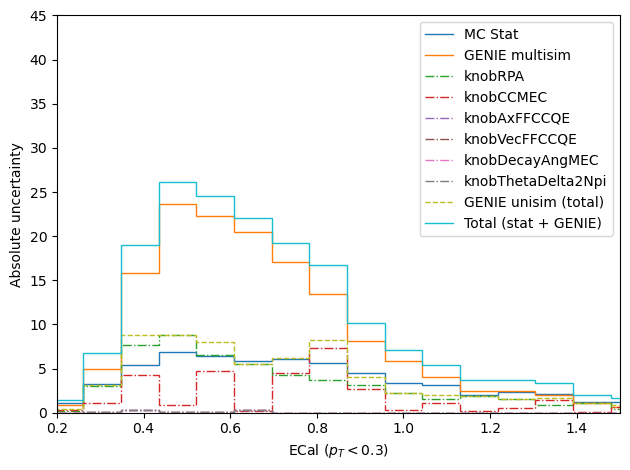


Using variable: ECal_pT02
bin counts: [  0.           0.           4.34163345  32.80097702  99.74777028
 150.64084883 151.94213258 136.72510196 113.93762127  84.76712216
  56.38761166  37.17611825  26.72334805  19.60450137  13.14913379
  10.85205567   5.50395533   5.4300172    4.67627372   0.67417582
   0.54593633   0.41665963   0.28012942]
MC stat absolute error: [8.42936970e-08 8.42936970e-08 8.13478172e-01 2.57763627e+00
 4.38495360e+00 5.59143135e+00 5.25140080e+00 4.92626073e+00
 4.91567020e+00 4.51748444e+00 3.57275223e+00 2.79026042e+00
 2.61515876e+00 1.80835548e+00 1.92098922e+00 1.75849099e+00
 8.82663444e-01 1.21251675e+00 1.83493058e+00 3.01595695e-01
 2.73412508e-01 2.40832538e-01 1.98277249e-01]

GENIE multisim absolute error: [ 0.          0.          0.72205396  2.78735372  9.61487798 15.34819575
 16.08941505 14.63508826 11.60181037  9.30992208  5.65563206  3.91221324
  2.78559465  2.06011773  1.73597177  1.51633639  0.62002262  0.64852443
  0.88091458  0.07749519  0.0

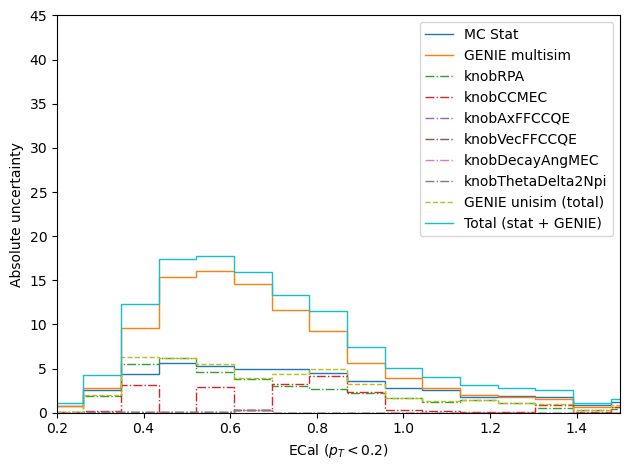

In [32]:
from microfit.statistics import covariance

edges = np.linspace(0.0, 1.0, 12)  # or your ECal edges, etc.

for var_name, var_edges, var_tex in my_vars:
    # Binning from ECal-like df column 
    binning = hist.Binning(
        variable=var_name,
        bin_edges=var_edges,
        label=var_name,
        variable_tex=var_tex,
    )
    print(f"\nUsing variable: {var_name}")

    # -----------------------
    # 1) MC stat only
    # -----------------------
    signal_generator_stat = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        detvar_data=None,
        uncertainty_defaults=None,
    )

    total_prediction_stat = signal_generator_stat.get_total_prediction(
        include_multisim_errors=False,
        add_precomputed_detsys=False,
    )

    bin_counts = total_prediction_stat.bin_counts
    print("bin counts:", bin_counts)

    # For now keep flux normalization trivial
    IntegratedFlux = 1.0

    # If you later divide by flux, do it here and also for all covariances
    flux_norm_total_prediction_stat = total_prediction_stat / IntegratedFlux
    stat_cov = flux_norm_total_prediction_stat.covariance_matrix

    # --- absolute MC stat error (same units as bin_counts / IntegratedFlux) ---
    stat_error_abs = np.sqrt(np.diag(stat_cov))
    print("MC stat absolute error:", stat_error_abs)
    print()

    # -----------------------
    # 2) Multisim: GENIE
    # -----------------------
    signal_generator_multisim = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
        detvar_data=None,
    )

    mc_hist_generator = signal_generator_multisim.mc_hist_generator

    # GENIE multisim covariance (same binning)
    genie_cov = mc_hist_generator.calculate_multisim_uncertainties(
        multisim_weight_column="weightsGenie"
    ) / IntegratedFlux**2

    # --- absolute GENIE multisim error ---
    genie_error_abs = np.sqrt(np.diag(genie_cov))
    print("GENIE multisim absolute error:", genie_error_abs)
    print()

    # -----------------------
    # 3) Unisim: total + per knob
    # -----------------------
    unisim_cov_total, unisim_hist_dict = mc_hist_generator.calculate_unisim_uncertainties(
        return_histograms=True,
        skip_covariance=False,   # so we also get the total covariance
    )

    # --- absolute GENIE unisim *total* error ---
    genie_unisim_total_abs = np.sqrt(np.diag(unisim_cov_total)) / IntegratedFlux
    print("GENIE unisim total absolute error:", genie_unisim_total_abs)
    print()

    # Central value histogram (same selection/binning) for per-knob cov
    central_hist = mc_hist_generator._histogram_multi_channel(mc_hist_generator.dataframe)
    cv_counts = central_hist.bin_counts  # same normalization as observations

    unisim_errors_per_knob_abs = {}
    for knob, observations in unisim_hist_dict.items():
        # observations shape: (n_universes, n_bins)
        cov_knob = covariance(
            observations,
            cv_counts,
            allow_approximation=True,
            tolerance=1e-8,
            debug_name=knob,
        ) / IntegratedFlux**2

        # --- absolute error per knob ---
        err_knob_abs = np.sqrt(np.diag(cov_knob))
        unisim_errors_per_knob_abs[knob] = err_knob_abs
        print(f"{knob} unisim absolute error:", err_knob_abs)

    # Optionally: total (stat + multisim + unisim-total) absolute error per bin
    total_abs_error = np.sqrt(
        stat_error_abs**2 + genie_error_abs**2 + genie_unisim_total_abs**2
    )
    print("Total absolute error (stat + GENIE multi + unisim-total):", total_abs_error)
    print()

    # -----------------------
    # 4) Plot absolute uncertainties
    # -----------------------
    fig, ax = plt.subplots()

    ax.stairs(stat_error_abs, var_edges, label="MC Stat")

    ax.stairs(
        genie_error_abs,
        var_edges,
        label="GENIE multisim",
    )

    # Example: only dominant knobs
    for knob in ["knobRPA", "knobCCMEC", "knobAxFFCCQE",
                 "knobVecFFCCQE", "knobDecayAngMEC", "knobThetaDelta2Npi"]:
        if knob in unisim_errors_per_knob_abs:
            ax.stairs(
                unisim_errors_per_knob_abs[knob],
                var_edges,
                label=knob,
                linestyle="dashdot",
            )

    # Plot total unisim if you want
    ax.stairs(
        genie_unisim_total_abs,
        var_edges,
        label="GENIE unisim (total)",
        linestyle="dashed",
    )

    # And / or total combined error
    ax.stairs(
        total_abs_error,
        var_edges,
        label="Total (stat + GENIE)",
        linestyle="solid",
    )

    ax.set_xlabel(var_tex)
    ax.set_ylabel("Absolute uncertainty")
    ax.legend(loc="best")
    ax.set_ylim(0, 45)
    ax.set_xlim(0.20, 1.50) 
    plt.tight_layout()
    plt.show()
    plt.close()


### ONLY MC STATS

/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:48: RuntimeWarning: divide by zero encountered in true_divide


ValueError: Axis limits cannot be NaN or Inf

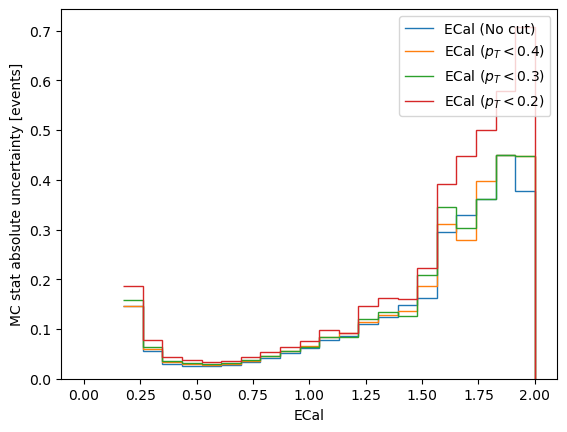

In [35]:
from microfit import histogram as hist
import numpy as np
import matplotlib.pyplot as plt

IntegratedFlux = 1.0  # keep as 1 for now

# my_vars already defined, e.g.:
# my_vars = [
#     ("ECal_all",  edges, r"ECal (No cut)"),
#     ("ECal_pT04", edges, r"ECal ($p_T<0.4$)"),
#     ("ECal_pT03", edges, r"ECal ($p_T<0.3$)"),
#     ("ECal_pT02", edges, r"ECal ($p_T<0.2$)"),
# ]

stat_errors_by_var = {}

for var_name, var_edges, var_tex in my_vars:
    binning = hist.Binning(
        variable=var_name,
        bin_edges=var_edges,
        label=var_name,
        variable_tex=var_tex,
    )

    # MC stat only
    signal_generator_stat = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        detvar_data=None,
        uncertainty_defaults=None,
    )

    total_prediction_stat = signal_generator_stat.get_total_prediction(
        include_multisim_errors=False,
        add_precomputed_detsys=False,
    )

    bin_counts = total_prediction_stat.bin_counts

    # covariance in same units as bin_counts / IntegratedFlux
    flux_norm_total_prediction_stat = total_prediction_stat / IntegratedFlux
    stat_cov = flux_norm_total_prediction_stat.covariance_matrix

    # absolute MC stat error (events per bin)
    stat_error_abs = np.sqrt(np.diag(stat_cov))

    # store for joint plot
    stat_errors_by_var[var_name] = (var_edges, stat_error_abs, var_tex)

# -------------------------------------------------
# Single plot: MC stat error for all selections
# -------------------------------------------------
fig, ax = plt.subplots()

for var_name, (var_edges, stat_err_abs, var_tex) in stat_errors_by_var.items():
    ax.stairs(stat_err_abs, var_edges, label=var_tex)

ax.set_xlabel(r"ECal")  # or use something more specific if you like
ax.set_ylabel("MC stat absolute uncertainty [events]")
ax.legend(loc="best")

# nice y and x limits
max_err = max(np.nanmax(err) for _, err, _ in stat_errors_by_var.values())
ax.set_ylim(0, 1.1 * max_err)
ax.set_xlim(my_vars[0][1][0], my_vars[0][1][-1])  # assumes same_


## PER BIN Analysis

In [ ]:
for col in ["is_signal", "mc_is_signal", "mc_is_cc0pi_signal", "mc_is_cc0pi_wc_signal"]:
    if col in mc.columns:
        vals = mc[col].value_counts(dropna=False)
        wsum = mc.loc[mc[col] == True, "weights"].sum()
        print(f"\nColumn: {col}")
        print(vals)
        print(f"  weighted sum for {col}==True: {wsum:.3f}")


In [ ]:
from microfit import selections as sel
import numpy as np

preselection = "sel_CCNp0pi"
selection    = "sel_CC1p0pi"

pre_q  = sel.preselection_categories[preselection]["query"]   # "sel_CCNp0pi"
sel_q  = sel.selection_categories[selection]["query"]         # "sel_CC1p0pi"
reco_q = f"({pre_q}) and ({sel_q})"

def wsum(df):
    return df["weights"].sum()

truth_defs = {
    "is_signal":              "is_signal == True",
    "mc_is_signal":           "mc_is_signal == True",
    "mc_is_cc1p0pi_signal":     "mc_is_cc1p0pi_signal == True",
    "mc_is_cc0pi_wc_signal":  "mc_is_cc0pi_wc_signal == True",
}

print(len(mc))
N_tot = wsum(mc)
print(f"Total MC (all): {N_tot:.3f}\n")

for label, signal_query in truth_defs.items():
    if label not in mc.columns:
        # (just skip missing ones, in case)
        pass
    
    sig_all   = mc.query(signal_query, engine="python")
    sel_all   = mc.query(reco_q,      engine="python")
    sel_sig   = mc.query(f"{signal_query} and {reco_q}", engine="python")

    N_sig_all = wsum(sig_all)
    N_sel_all = wsum(sel_all)
    N_sel_sig = wsum(sel_sig)

    eff  = N_sel_sig / N_sig_all if N_sig_all > 0 else np.nan
    pur  = N_sel_sig / N_sel_all if N_sel_all > 0 else np.nan
    rate = N_sel_all / N_tot      if N_tot    > 0 else np.nan

    print(f"=== Truth flag: {label} ===")
    print(f"  Truth signal (no reco cuts):    {N_sig_all:.3f}")
    print(f"  Reco selected (pre+sel):        {N_sel_all:.3f}")
    print(f"  Selected signal (truth+reco):   {N_sel_sig:.3f}")
    print(f"  Efficiency (truth → selected):  {eff*100:.2f} %")
    print(f"  Purity (selected signal frac):  {pur*100:.2f} %")
    print(f"  Rate vs all MC:                 {rate*100:.2f} %\n")


In [ ]:
truth_col = "mc_is_cc0pi_signal"

print("\nCrosstab (unweighted counts):")
print(pd.crosstab(mc[truth_col], mc["sel_CC1p0pi"]))

print("\nCrosstab (weighted):")
print(
    mc.groupby([truth_col, "sel_CC1p0pi"])["weights"].sum().unstack(fill_value=0)
)
